# 실험 2: Setting A — RetinaVLM 베이스라인 추론 + XAI 분석

**IRB 프로토콜 Setting A (Baseline):**
> 원본 OCT 이미지 + 텍스트 프롬프트 입력

RetinaVLM (ResNet50→Adapter→LLaMA3)을 사용하여 OCT 이미지에 대해
임상 보고서를 생성하고, 전체 파이프라인에 대한 XAI 분석을 수행합니다.

**입력:** 원본 OCT 이미지 + 텍스트 쿼리 (XAI 정보 없음)
**출력:** 임상 보고서 + ResNet GradCAM + LLM Attention 히트맵

**비교 대상:** 실험 3 (Setting B)의 XAI-Enhanced 결과

**파이프라인:**
```
원본 OCT → ResNet50 → Adapter → LLaMA3 → 리포트
               ↓                    ↓
          GradCAM 추출        LLM Attention 추출
               ↓                    ↓
          → 실험 3에서 Setting B와 비교
```

## 1. Imports & Hydra Config

In [2]:
import torch
import json
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from glob import glob
from datetime import datetime
from collections import Counter
import torch.nn.functional as F
import warnings
warnings.filterwarnings("ignore")

# SpecialistVLMs 경로
SPECIALIST_DIR = os.path.abspath("../SpecialistVLMs")
if SPECIALIST_DIR not in sys.path:
    sys.path.insert(0, SPECIALIST_DIR)
os.chdir(SPECIALIST_DIR)  # Hydra config 등 상대 경로 해결

from huggingface_hub import hf_hub_download
from safetensors.torch import load_file as safetensors_load_file
from omegaconf import OmegaConf
from hydra import compose, initialize_config_dir
from models.retinavlm_wrapper import RetinaVLM, RetinaVLMConfig

# Hydra config
config_dir = os.path.abspath("configs")
with initialize_config_dir(version_base=None, config_dir=config_dir):
    config = compose(config_name="default")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Config loaded: language_model={config.model.language_model.model_id}")

Device: cuda
Config loaded: language_model=meta-llama/Meta-Llama-3-8B-Instruct


## 2. 실험 파라미터

In [3]:
# =====================================================
#  실험 파라미터
# =====================================================

# 데이터 경로
DATA_DIR = "/home/ubuntu/bionexus/jgy/OCT_LLM_XAI/data/OCT2017/OCT2017 "
SAVE_DIR = "saved_models/RetinaVLM-Specialist-Dequantized"

# 실험 대상 클래스
CLASS_NAMES = ["NORMAL", "CNV"]

# 추론 설정
MAX_IMAGES_PER_CLASS = 25     # 클래스당 추론할 이미지 수
MAX_NEW_TOKENS = 300

# 쿼리 정의
QUERIES = {
    "report": "Write a detailed clinical report describing this OCT scan. "
              "Identify any visible biomarkers such as drusen, fluid, or atrophy.",
    "diagnosis": "Based on this OCT scan, what is the most likely diagnosis? "
                 "Provide reasoning.",
}
ACTIVE_QUERY = "report"

# 출력 디렉토리
EXP_DIR = "/home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments"
OUTPUT_DIR = os.path.join(EXP_DIR, "exp2_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "xai_resnet"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "xai_attention"), exist_ok=True)

print(f"Data: {DATA_DIR}")
print(f"Output: {OUTPUT_DIR}")
print(f"Query: {ACTIVE_QUERY}")

Data: /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/data/OCT2017/OCT2017 
Output: /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp2_outputs
Query: report


## 3. RetinaVLM 모델 로드 (Method 1: Dequantized)

In [4]:
# Config 로드
rvlm_config = RetinaVLMConfig.from_pretrained(
    "RobbieHolland/RetinaVLM", subfolder="RetinaVLM-Specialist"
)
rvlm_config.update(config)
rvlm_config.model.checkpoint_path = None

# 모델 생성
print("Creating RetinaVLM model...")
model = RetinaVLM(rvlm_config)

# Dequantized state_dict 로드
print("Loading dequantized checkpoint...")
state_dict = torch.load(os.path.join(SAVE_DIR, "model.pt"), map_location="cpu")
missing, unexpected = model.load_state_dict(state_dict, strict=False)
print(f"  Loaded: {len(state_dict) - len(unexpected)} keys | "
      f"Missing: {len(missing)} | Unexpected: {len(unexpected)}")
del state_dict

model.to(DEVICE)
model.eval()
print(f"\nRetinaVLM ready on {DEVICE} (Method 1: Dequantized, 0 missing keys)")

`torch_dtype` is deprecated! Use `dtype` instead!


Creating RetinaVLM model...
Creating new MiniGPT4 model
Loading image encoder
Creating blank encoder for later weight loading.
Loading image encoder Done
Loading language model


Loading weights: 100%|██████████| 291/291 [00:19<00:00, 15.21it/s] 


Loading language model Done
Linear projection Linear(in_features=2048, out_features=4096, bias=True)
MiniGPT-4 has 8392704 trainable parameters
Creating an entirely new MiniGPT4 adapter (this will be overwritten by pretrained model if loaded from API)
Loading dequantized checkpoint...
  Loaded: 1220 keys | Missing: 0 | Unexpected: 0

RetinaVLM ready on cuda (Method 1: Dequantized, 0 missing keys)


## 4. 테스트 이미지 준비 & 추론

In [5]:
# 테스트 이미지 수집
test_images = []
for cls_name in CLASS_NAMES:
    cls_dir = os.path.join(DATA_DIR, "test", cls_name)
    files = sorted(glob(os.path.join(cls_dir, "*.jpeg")) +
                  glob(os.path.join(cls_dir, "*.png")))
    if MAX_IMAGES_PER_CLASS:
        files = files[:MAX_IMAGES_PER_CLASS]
    for f in files:
        test_images.append({"path": f, "class": cls_name})

print(f"Total test images: {len(test_images)}")
for cls in CLASS_NAMES:
    n = sum(1 for t in test_images if t["class"] == cls)
    print(f"  {cls}: {n}")

# 추론 실행
query_text = QUERIES[ACTIVE_QUERY]
results = []

print(f"\nQuery: {query_text[:80]}...")
print("-" * 60)

for i, item in enumerate(test_images):
    image = np.array(Image.open(item["path"]).convert("L"))
    fname = os.path.basename(item["path"])

    start = time.time()
    with torch.no_grad():
        outputs = model.forward([image], [query_text], max_new_tokens=MAX_NEW_TOKENS)
    elapsed = time.time() - start

    results.append({
        "image": fname,
        "class": item["class"],
        "path": item["path"],
        "response": outputs[0],
        "n_words": len(outputs[0].split()),
        "time_sec": round(elapsed, 2),
    })

    if (i + 1) % 10 == 0 or i == 0:
        print(f"  [{i+1}/{len(test_images)}] {fname[:35]}... | {item['class']} | "
              f"{len(outputs[0].split())} words | {elapsed:.1f}s")

print("-" * 60)
print(f"Total: {len(results)} images | avg {np.mean([r['time_sec'] for r in results]):.1f}s/image")

# 결과 저장
df_results = pd.DataFrame(results)
df_results.to_csv(os.path.join(OUTPUT_DIR, "inference_results.csv"), index=False)
with open(os.path.join(OUTPUT_DIR, "inference_results.json"), "w") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
print(f"Results saved to {OUTPUT_DIR}/")

Total test images: 50
  NORMAL: 25
  CNV: 25

Query: Write a detailed clinical report describing this OCT scan. Identify any visible ...
------------------------------------------------------------


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


Inputs torch.Size([1, 112, 4096])


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


  [1/50] NORMAL-1017237-1.jpeg... | NORMAL | 106 words | 5.1s
Inputs torch.Size([1, 112, 4096])


...

Inputs torch.Size([1, 112, 4096])


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


Inputs torch.Size([1, 112, 4096])


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


Inputs torch.Size([1, 112, 4096])
  [50/50] CNV-1188386-2.jpeg... | CNV | 39 words | 1.1s
------------------------------------------------------------
Total: 50 images | avg 1.7s/image
Results saved to /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp2_outputs/


## 5. 응답 분석: 클래스별 키워드 감지

In [6]:
BIOMARKERS = [
    "drusen", "fluid", "subretinal fluid", "intraretinal fluid",
    "PED", "pigment epithelial detachment",
    "atrophy", "geographic atrophy", "RPE atrophy",
    "SHRM", "subretinal hyperreflective material",
    "ERM", "epiretinal membrane", "edema", "macular edema",
    "CNV", "choroidal neovascularization", "hypertransmission",
    "AMD", "age-related macular degeneration",
    "normal", "healthy", "unremarkable",
]

def extract_keywords(text, keywords):
    return [kw for kw in keywords if kw.lower() in text.lower()]

# 클래스별 키워드 분석
for cls in CLASS_NAMES:
    cls_results = [r for r in results if r["class"] == cls]
    print(f"\n{'='*50}")
    print(f" {cls} class ({len(cls_results)} images)")
    print(f"{'='*50}")

    kw_counts = Counter()
    for r in cls_results:
        for kw in extract_keywords(r["response"], BIOMARKERS):
            kw_counts[kw] += 1

    for kw, cnt in kw_counts.most_common(10):
        pct = cnt / len(cls_results) * 100
        print(f"  {kw:<40s} {cnt:>3d}/{len(cls_results)} ({pct:.0f}%)")

    # 샘플 응답 출력
    print(f"\n  [Sample Response]")
    print(f"  {cls_results[0]['response'][:200]}...")


 NORMAL class (25 images)
  drusen                                    25/25 (100%)
  fluid                                     25/25 (100%)
  atrophy                                   25/25 (100%)
  normal                                    25/25 (100%)
  healthy                                   20/25 (80%)
  AMD                                        6/25 (24%)
  intraretinal fluid                         5/25 (20%)
  subretinal fluid                           3/25 (12%)
  edema                                      3/25 (12%)
  macular edema                              3/25 (12%)

  [Sample Response]
  The OCT scan shows a relatively normal retinal structure with some minor irregularities. The retinal pigment epithelium (RPE) is intact, and there are no signs of significant drusen or fluid accumulat...

 CNV class (25 images)
  drusen                                    25/25 (100%)
  fluid                                     25/25 (100%)
  atrophy                                   

## 5-1. 환각(Hallucination) 감지 (Setting A 기준선)

NORMAL 이미지에서 병리학적 키워드가 나오면 거짓양성(환각)으로 판정합니다.
이 결과는 실험 3 (Setting B)와의 환각률 비교에 사용됩니다.

In [7]:
# 환각 판정 키워드
PATHOLOGY_KEYWORDS = [
    "cnv", "choroidal neovascularization", "neovascular",
    "drusen", "fluid", "subretinal fluid", "intraretinal fluid",
    "edema", "macular edema", "cystoid",
    "PED", "pigment epithelial detachment",
    "atrophy", "geographic atrophy",
    "SHRM", "subretinal hyperreflective material",
    "hemorrhage", "exudation", "fibrosis",
]
NORMAL_KEYWORDS = ["normal", "healthy", "unremarkable", "no abnormality", "no pathology"]


def detect_hallucinations(response_text, true_class):
    text_lower = response_text.lower()
    hallucinations = []
    if true_class == "NORMAL":
        for kw in PATHOLOGY_KEYWORDS:
            if kw.lower() in text_lower:
                hallucinations.append({"type": "false_positive", "keyword": kw})
    elif true_class == "CNV":
        has_pathology = any(kw.lower() in text_lower for kw in PATHOLOGY_KEYWORDS)
        has_normal_only = any(kw.lower() in text_lower for kw in NORMAL_KEYWORDS) and not has_pathology
        if has_normal_only:
            hallucinations.append({"type": "false_negative", "keyword": "normal/healthy only"})
    return hallucinations


# Setting A 환각 분석
hall_results = []
for r in results:
    h = detect_hallucinations(r["response"], r["class"])
    hall_results.append({
        "image": r["image"], "class": r["class"],
        "n_hallucinations": len(h), "details": h,
    })

print(f"{'='*60}")
print(f" Setting A 환각(Hallucination) 분석")
print(f"{'='*60}")

total = len(hall_results)
with_hall = sum(1 for h in hall_results if h["n_hallucinations"] > 0)
print(f"  전체: {with_hall}/{total} ({with_hall/total*100:.1f}%) 환각 포함")

for cls in CLASS_NAMES:
    cls_hall = [h for h in hall_results if h["class"] == cls]
    cls_with = sum(1 for h in cls_hall if h["n_hallucinations"] > 0)
    print(f"  {cls}: {cls_with}/{len(cls_hall)} ({cls_with/len(cls_hall)*100:.1f}%)")
    # 가장 흔한 환각 키워드
    kw_counts = Counter()
    for h in cls_hall:
        for d in h["details"]:
            kw_counts[d["keyword"]] += 1
    if kw_counts:
        print(f"    Top keywords: {', '.join(f'{k}({v})' for k,v in kw_counts.most_common(5))}")

# 저장 (실험 3에서 비교용으로 사용)
with open(os.path.join(OUTPUT_DIR, "hallucination_baseline.json"), "w") as f:
    json.dump(hall_results, f, indent=2, ensure_ascii=False)
print(f"\n  Saved to {OUTPUT_DIR}/hallucination_baseline.json")

 Setting A 환각(Hallucination) 분석
  전체: 25/50 (50.0%) 환각 포함
  NORMAL: 25/25 (100.0%)
    Top keywords: drusen(25), fluid(25), atrophy(25), intraretinal fluid(5), subretinal fluid(3)
  CNV: 0/25 (0.0%)

  Saved to /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp2_outputs/hallucination_baseline.json


## 6. ResNet Visual Encoder XAI (GradCAM)

In [8]:
# ResNet visual encoder에 GradCAM 적용
inner = model.model  # MiniGPT4 instance

# GradCAM을 위한 hook 설정
gradcam_data = {"activations": None, "gradients": None}

def save_act(m, i, o):
    gradcam_data["activations"] = o.detach()

def save_grad(m, gi, go):
    gradcam_data["gradients"] = go[0].detach()

# ResNet의 layer4에 hook 등록
target_layer = inner.visual_encoder.model.layer4
hook_fwd = target_layer.register_forward_hook(save_act)
hook_bwd = target_layer.register_full_backward_hook(save_grad)

print("Generating ResNet GradCAM heatmaps...")

import scipy.ndimage

model_param = next(inner.parameters())
model_dtype = model_param.dtype
model_device = model_param.device

n_xai = min(10, len(test_images))
xai_resnet_results = []

for idx in range(n_xai):
    item = test_images[idx]
    img_np = np.array(Image.open(item["path"]).convert("L"))
    fname_base = os.path.splitext(os.path.basename(item["path"]))[0]

    # 이미지 전처리 (RetinaVLM wrapper와 동일)
    img_arr = img_np[np.newaxis, :, :].copy()  # [1,H,W]
    if img_arr.shape[1] != 192 or img_arr.shape[2] != 192:
        zoom_factors = [1, 192 / img_arr.shape[1], 192 / img_arr.shape[2]]
        img_arr = scipy.ndimage.zoom(img_arr, zoom_factors, order=1)
    img_arr = img_arr.astype(np.float32) / 255.0
    img_tensor = torch.from_numpy(img_arr).unsqueeze(0).to(device=model_device, dtype=model_dtype)
    img_tensor.requires_grad_(True)

    # ResNet backbone 수동 forward (PretrainedResNet에 forward()가 없으므로)
    backbone = inner.visual_encoder.model
    x = backbone.conv1(img_tensor)
    x = backbone.bn1(x)
    x = backbone.relu(x)
    x = backbone.maxpool(x)
    x = backbone.layer1(x)
    x = backbone.layer2(x)
    x = backbone.layer3(x)
    x = backbone.layer4(x)  # hook이 여기서 activation/gradient 캡처

    target = x.mean()
    target.backward()

    if gradcam_data["gradients"] is not None and gradcam_data["activations"] is not None:
        grads = gradcam_data["gradients"]
        acts = gradcam_data["activations"]
        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * acts).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=(224, 224), mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().detach().numpy()
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        # 저장
        save_path = os.path.join(OUTPUT_DIR, "xai_resnet", f"{fname_base}_resnet_gradcam.png")
        npy_path = os.path.join(OUTPUT_DIR, "xai_resnet", f"{fname_base}_resnet_gradcam.npy")
        display_img = np.array(Image.open(item["path"]).convert("L").resize((224, 224)))

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(display_img, cmap="gray")
        axes[0].set_title(f"{item['class']}", fontsize=10); axes[0].axis("off")
        axes[1].imshow(display_img, cmap="gray")
        axes[1].imshow(cam, cmap="jet", alpha=0.5)
        axes[1].set_title("ResNet GradCAM", fontsize=10); axes[1].axis("off")
        plt.tight_layout()
        plt.savefig(save_path, dpi=100, bbox_inches="tight")
        plt.close()

        np.save(npy_path, cam)
        xai_resnet_results.append({"image": fname_base, "class": item["class"],
                                   "file_png": save_path, "file_npy": npy_path})
        print(f"  [{idx+1}/{n_xai}] {fname_base} ({item['class']})")

    inner.zero_grad()

hook_fwd.remove()
hook_bwd.remove()

# 결과 저장
with open(os.path.join(OUTPUT_DIR, "xai_resnet", "resnet_gradcam_results.json"), "w") as f:
    json.dump(xai_resnet_results, f, indent=2, ensure_ascii=False)
print(f"\nResNet GradCAM: {len(xai_resnet_results)}/{n_xai} saved to {OUTPUT_DIR}/xai_resnet/")

Generating ResNet GradCAM heatmaps...
  [1/10] NORMAL-1017237-1 (NORMAL)
  [2/10] NORMAL-101880-1 (NORMAL)
  [3/10] NORMAL-1025847-1 (NORMAL)
  [4/10] NORMAL-1038998-1 (NORMAL)
  [5/10] NORMAL-1042462-1 (NORMAL)
  [6/10] NORMAL-1058176-1 (NORMAL)
  [7/10] NORMAL-1063128-1 (NORMAL)
  [8/10] NORMAL-1073137-1 (NORMAL)
  [9/10] NORMAL-1081406-1 (NORMAL)
  [10/10] NORMAL-112928-1 (NORMAL)

ResNet GradCAM: 10/10 saved to /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp2_outputs/xai_resnet/


## 7. LLM Attention 시각화

In [9]:
# =====================================================
# LLM Attention 히트맵 추출 및 시각화
# =====================================================
# MiniGPT4의 attention() 메서드를 사용하여 LLM이 이미지 토큰에
# 얼마나 주목하는지 추출합니다.
#
# 핵심: sdpa → eager 전환 후 output_attentions=True 사용
# subsequence_indices로 이미지 토큰 위치를 파악하여
# attention을 6x6 공간 그리드로 복원 → 히트맵 생성

inner = model.model  # MiniGPT4 instance
llm_hf = inner.llama_model  # HuggingFace LlamaForCausalLM

# 1) sdpa → eager 전환 (output_attentions 지원을 위해)
llm_hf.config._attn_implementation = "eager"
for layer in llm_hf.model.layers:
    layer.self_attn._attn_implementation = "eager"
print("Switched LLM attention to 'eager' mode")

# 2) 이미지 전처리 함수 (RetinaVLM wrapper와 동일)
def prepare_image_tensor(img_np, device, dtype):
    """numpy grayscale → [1,1,192,192] normalized tensor"""
    if img_np.ndim == 2:
        img_np = img_np[np.newaxis, :, :]  # [1,H,W]
    import scipy.ndimage
    if img_np.shape[1] != 192 or img_np.shape[2] != 192:
        zoom_factors = [1, 192 / img_np.shape[1], 192 / img_np.shape[2]]
        img_np = scipy.ndimage.zoom(img_np, zoom_factors, order=1)
    if not np.issubdtype(img_np.dtype, np.floating):
        img_np = img_np.astype(np.float32) / 255.0
    return torch.from_numpy(img_np).unsqueeze(0).to(device=device, dtype=dtype)

# 3) Attention 추출 & 시각화
n_attn = min(10, len(test_images))
attn_results = []
query_text_attn = QUERIES[ACTIVE_QUERY]

print(f"\nExtracting LLM attention for {n_attn} images...")
print("-" * 60)

model_param = next(inner.parameters())
model_dtype = model_param.dtype
model_device = model_param.device

for idx in range(n_attn):
    item = test_images[idx]
    img_np = np.array(Image.open(item["path"]).convert("L"))
    fname_base = os.path.splitext(os.path.basename(item["path"]))[0]

    # 이미지 텐서 준비
    img_tensor = prepare_image_tensor(img_np, model_device, model_dtype)

    try:
        with torch.no_grad():
            # MiniGPT4.attention() 호출 — 정상적인 form_input 사용, 커스텀 마스크 없음
            samples, tokens, subseq_indices, seq_attentions, _ = inner.attention(
                img_tensor, [query_text_attn]
            )
        # seq_attentions shape: [n_layers, batch, n_heads, seq_len, seq_len]
        # subseq_indices[0] = (pre_tokens, img_tokens, post_tokens)

        pre_len, img_len, post_len = subseq_indices[0]
        total_seq = pre_len + img_len + post_len

        # 모든 레이어/헤드의 평균 attention: 텍스트 토큰 → 이미지 토큰
        # post_tokens (질문/답변 텍스트)이 image tokens에 주는 attention
        text_to_img_attn = seq_attentions[:, 0, :, pre_len + img_len:, pre_len:pre_len + img_len]
        # 평균: 레이어, 헤드, 텍스트 위치 모두 평균
        avg_attn = text_to_img_attn.mean(dim=(0, 1, 2)).numpy()  # [img_len]

        # 6x6 공간 그리드로 복원 (ResNet50 192→6x6)
        spatial_size = int(np.sqrt(img_len))
        if spatial_size * spatial_size == img_len:
            attn_map = avg_attn.reshape(spatial_size, spatial_size)
        else:
            # p/s tokens 포함 시 이미지 토큰만 추출
            attn_map = avg_attn[:spatial_size * spatial_size].reshape(spatial_size, spatial_size)

        # 정규화
        if attn_map.max() > attn_map.min():
            attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())

        # 원본 해상도로 업스케일
        from PIL import Image as PILImage
        attn_upscaled = np.array(PILImage.fromarray(attn_map.astype(np.float32)).resize(
            (224, 224), PILImage.BILINEAR))

        # 시각화 & 저장
        display_img = np.array(Image.open(item["path"]).convert("L").resize((224, 224)))
        save_path = os.path.join(OUTPUT_DIR, "xai_attention", f"{fname_base}_llm_attention.png")
        npy_path = os.path.join(OUTPUT_DIR, "xai_attention", f"{fname_base}_llm_attention.npy")

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(display_img, cmap="gray")
        axes[0].set_title(f"{item['class']}", fontsize=10); axes[0].axis("off")
        axes[1].imshow(attn_map, cmap="hot", interpolation="nearest")
        axes[1].set_title(f"LLM Attention ({spatial_size}x{spatial_size})", fontsize=10); axes[1].axis("off")
        axes[2].imshow(display_img, cmap="gray")
        axes[2].imshow(attn_upscaled, cmap="hot", alpha=0.5)
        axes[2].set_title("LLM Attention Overlay", fontsize=10); axes[2].axis("off")
        plt.suptitle(f"{fname_base} | img_tokens={img_len} | layers={seq_attentions.shape[0]}", fontsize=9)
        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close()

        np.save(npy_path, attn_map)

        attn_results.append({
            "image": fname_base,
            "class": item["class"],
            "img_tokens": int(img_len),
            "spatial_size": spatial_size,
            "attn_mean": float(avg_attn.mean()),
            "attn_max": float(avg_attn.max()),
            "file_png": save_path,
            "file_npy": npy_path,
        })
        print(f"  [{idx+1}/{n_attn}] {fname_base} ({item['class']}) | "
              f"img_tokens={img_len}, grid={spatial_size}x{spatial_size}")

    except Exception as e:
        print(f"  [{idx+1}/{n_attn}] {fname_base} - ERROR: {e}")
        import traceback; traceback.print_exc()

    # GPU 메모리 정리
    torch.cuda.empty_cache()

# 결과 저장
with open(os.path.join(OUTPUT_DIR, "xai_attention", "llm_attention_results.json"), "w") as f:
    json.dump(attn_results, f, indent=2, ensure_ascii=False)

print(f"\n{'='*60}")
print(f"LLM Attention heatmaps: {len(attn_results)}/{n_attn} saved")
print(f"Output: {OUTPUT_DIR}/xai_attention/")
print(f"{'='*60}")

Switched LLM attention to 'eager' mode

Extracting LLM attention for 10 images...
------------------------------------------------------------
  [1/10] NORMAL-1017237-1 (NORMAL) | img_tokens=36, grid=6x6
  [2/10] NORMAL-101880-1 (NORMAL) | img_tokens=36, grid=6x6
  [3/10] NORMAL-1025847-1 (NORMAL) | img_tokens=36, grid=6x6
  [4/10] NORMAL-1038998-1 (NORMAL) | img_tokens=36, grid=6x6
  [5/10] NORMAL-1042462-1 (NORMAL) | img_tokens=36, grid=6x6
  [6/10] NORMAL-1058176-1 (NORMAL) | img_tokens=36, grid=6x6
  [7/10] NORMAL-1063128-1 (NORMAL) | img_tokens=36, grid=6x6
  [8/10] NORMAL-1073137-1 (NORMAL) | img_tokens=36, grid=6x6
  [9/10] NORMAL-1081406-1 (NORMAL) | img_tokens=36, grid=6x6
  [10/10] NORMAL-112928-1 (NORMAL) | img_tokens=36, grid=6x6

LLM Attention heatmaps: 10/10 saved
Output: /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp2_outputs/xai_attention/


## 8. 결과 시각화 & 저장

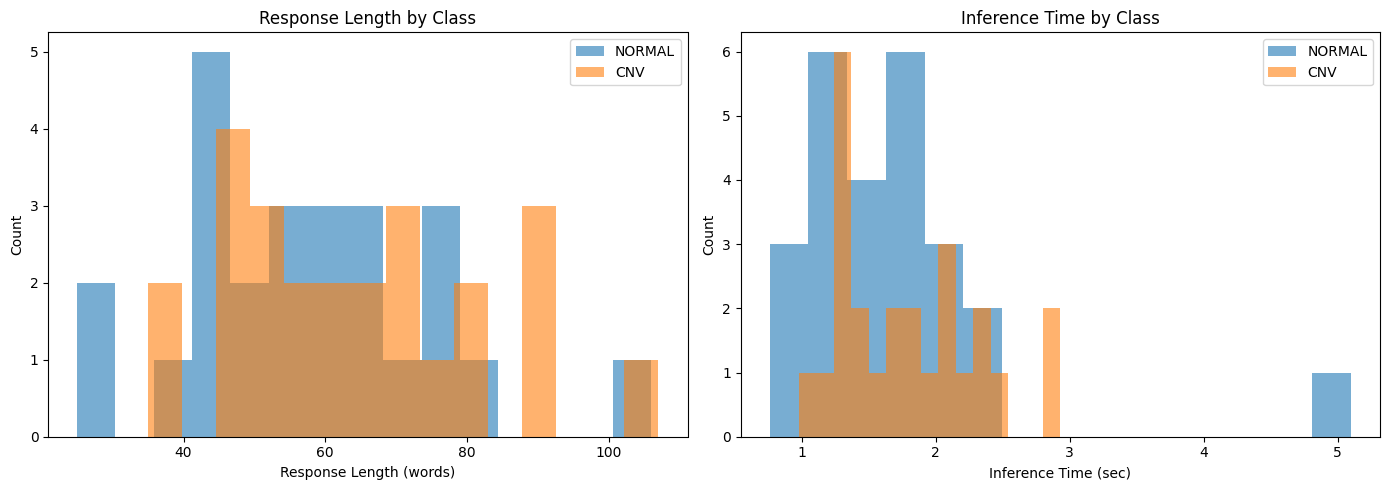


 실험 2 완료!
 추론 결과: /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp2_outputs/inference_results.csv
 ResNet XAI: /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp2_outputs/xai_resnet/
 LLM Attn:   /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp2_outputs/xai_attention/


In [10]:
# 클래스별 응답 통계
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, cls in enumerate(CLASS_NAMES):
    cls_data = [r for r in results if r["class"] == cls]
    words = [r["n_words"] for r in cls_data]
    times = [r["time_sec"] for r in cls_data]
    axes[0].hist(words, bins=15, alpha=0.6, label=cls)
    axes[1].hist(times, bins=15, alpha=0.6, label=cls)

axes[0].set_xlabel("Response Length (words)"); axes[0].set_ylabel("Count")
axes[0].set_title("Response Length by Class"); axes[0].legend()
axes[1].set_xlabel("Inference Time (sec)"); axes[1].set_ylabel("Count")
axes[1].set_title("Inference Time by Class"); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "response_stats.png"), dpi=150, bbox_inches="tight")
plt.show()

# 실험 로그
log = {
    "experiment": "exp2_retinavlm_baseline",
    "method": "method1_dequantized",
    "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
    "device": str(DEVICE),
    "query": ACTIVE_QUERY,
    "total_images": len(results),
    "per_class": {cls: sum(1 for r in results if r["class"] == cls) for cls in CLASS_NAMES},
    "avg_words": round(np.mean([r["n_words"] for r in results]), 1),
    "avg_time": round(np.mean([r["time_sec"] for r in results]), 2),
}
with open(os.path.join(OUTPUT_DIR, "experiment_log.json"), "w") as f:
    json.dump(log, f, indent=2, ensure_ascii=False)

print(f"\n{'='*60}")
print(f" 실험 2 완료!")
print(f" 추론 결과: {OUTPUT_DIR}/inference_results.csv")
print(f" ResNet XAI: {OUTPUT_DIR}/xai_resnet/")
print(f" LLM Attn:   {OUTPUT_DIR}/xai_attention/")
print(f"{'='*60}")